In [20]:
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
llm=ChatOpenAI()

class State(TypedDict):
    messages:Annotated[list,add_messages]

In [1]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [21]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

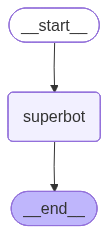

In [22]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(State)

graph.add_node("superbot",superbot)

graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder=graph.compile(memory)

from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

Updates

In [29]:
config={"configurable":{"thread_id":"1"}}
for chunck in graph_builder.stream({"messages":"Hi my name is Aditya"},config,stream_mode="updates"):
    print(chunck)



{'superbot': {'messages': [AIMessage(content="Hello Aditya! It's nice to meet you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 238, 'total_tokens': 257, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DYW5U4KoXRkceUXPVZYfaYNu6urdH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc489-ee09-71b3-b9c5-fc10d312d637-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 238, 'output_tokens': 19, 'total_tokens': 257, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


Values

In [30]:
for chunck in graph_builder.stream({"messages":"Hi my name is Aditya"},config,stream_mode="values"):
    print(chunck)


{'messages': [HumanMessage(content='Hi my name is Aditya', additional_kwargs={}, response_metadata={}, id='b39f56b6-98ce-4e2e-b3e1-dfe99ed769ab'), AIMessage(content="Hello Aditya, it's nice to meet you! How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 14, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DYW3B1aBXfm1tJ0YuuDd0TyfyRxVt', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc487-be2b-75b0-9545-9c95c0191880-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 19, 'total_tokens': 33, 'input_token_details': {'audio': 0, 'cache_r

In [33]:
async for chunck in graph_builder.astream_events({"messages":"Hi my name is Aditya"},config,stream_mode="values", version="v2"):
        print(chunck)


{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is Aditya'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019dc48d-d681-77d0-88d8-6da40f08d42d', 'metadata': {'thread_id': '1', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '019dc48d-d681-77d0-88d8-6da40f08d42d', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '1', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='Hi my name is Aditya', additional_kwargs={}, response_metadata={}, id='b39f56b6-98ce-4e2e-b3e1-dfe99ed769ab'), AIMessage(content="Hello Aditya, it's nice to meet you! How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 14, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'ca